# Model V1 -- Keeping the unknowns as is

## Data Loading and Mapping

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score
import warnings

warnings.filterwarnings('ignore')

df = pd.read_csv('filtered_data.csv')

df.head()

,_BMI5,_BMI5CAT,_AGE_G,_AGE80,_AGE65YR,_INCOMG1,INCOME3,_SMOKER3,_RFSMOK3,SMOKDAY2,...,MENTHLTH,ADDEPEV3,LANDSEX3,SEXVAR,DIABETE4,PERSDOC3,PRIMINS2,_URBSTAT,_IMPRACE,CHILDREN
0,2249.0,2.0,6.0,78.0,2.0,9.0,99.0,4.0,1.0,NaN,...,88.0,2.0,2.0,2.0,3.0,2.0,3.0,1.0,1.0,88.0
1,2583.0,3.0,6.0,80.0,2.0,7.0,11.0,3.0,1.0,3.0,...,88.0,2.0,1.0,1.0,3.0,1.0,3.0,1.0,1.0,88.0
2,2253.0,2.0,5.0,59.0,1.0,9.0,99.0,1.0,2.0,1.0,...,88.0,2.0,1.0,1.0,3.0,3.0,1.0,1.0,1.0,88.0
3,2509.0,3.0,6.0,80.0,2.0,4.0,6.0,4.0,1.0,NaN,...,88.0,2.0,1.0,1.0,3.0,1.0,3.0,1.0,1.0,88.0
4,1977.0,2.0,4.0,47.0,1.0,2.0,3.0,4.0,1.0,NaN,...,88.0,2.0,1.0,1.0,3.0,1.0,5.0,1.0,1.0,88.0


In [5]:
df.columns

Index(['_BMI5', '_BMI5CAT', '_AGE_G', '_AGE80', '_AGE65YR', '_INCOMG1',
       'INCOME3', '_SMOKER3', '_RFSMOK3', 'SMOKDAY2', 'CVDINFR4', 'CVDCRHD4',
       'ASTHMA3', '_LTASTH1', 'CHCKDNY2', 'MARITAL', 'EDUCA', '_EDUCAG',
       'GENHLTH', 'EXERANY2', '_TOTINDA', 'HAVARTH4', '_DRDXAR2', 'MENTHLTH',
       'ADDEPEV3', 'LANDSEX3', 'SEXVAR', 'DIABETE4', 'PERSDOC3', 'PRIMINS2',
       '_URBSTAT', '_IMPRACE', 'CHILDREN'],
      dtype='str')

In [6]:
chosen_columns = ['_BMI5', '_AGE_G', 'INCOME3', '_SMOKER3', 'CVDINFR4', 'CVDCRHD4',
                 'ASTHMA3', 'CHCKDNY2', 'MARITAL', 'EDUCA', 'GENHLTH', 'EXERANY2',
                 'HAVARTH4', 'MENTHLTH', 'ADDEPEV3', 'SEXVAR', 'PERSDOC3', 'PRIMINS2',
                 '_URBSTAT', 'CHILDREN', 'DIABETE4']

df_eda = df[chosen_columns]

In [7]:
df_eda.head()

,_BMI5,_AGE_G,INCOME3,_SMOKER3,CVDINFR4,CVDCRHD4,ASTHMA3,CHCKDNY2,MARITAL,EDUCA,...,EXERANY2,HAVARTH4,MENTHLTH,ADDEPEV3,SEXVAR,PERSDOC3,PRIMINS2,_URBSTAT,CHILDREN,DIABETE4
0,2249.0,6.0,99.0,4.0,2.0,2.0,2.0,2.0,3.0,4.0,...,1.0,1.0,88.0,2.0,2.0,2.0,3.0,1.0,88.0,3.0
1,2583.0,6.0,11.0,3.0,2.0,1.0,2.0,2.0,1.0,6.0,...,1.0,1.0,88.0,2.0,1.0,1.0,3.0,1.0,88.0,3.0
2,2253.0,5.0,99.0,1.0,2.0,2.0,2.0,2.0,6.0,5.0,...,1.0,1.0,88.0,2.0,1.0,3.0,1.0,1.0,88.0,3.0
3,2509.0,6.0,6.0,4.0,2.0,2.0,2.0,2.0,1.0,6.0,...,1.0,1.0,88.0,2.0,1.0,1.0,3.0,1.0,88.0,3.0
4,1977.0,4.0,3.0,4.0,2.0,2.0,2.0,2.0,5.0,5.0,...,2.0,2.0,88.0,2.0,1.0,1.0,5.0,1.0,88.0,3.0


In [8]:
df_eda['DIABETE4'] = df_eda['DIABETE4'].map({
    1: 1,          # Yes
    2: np.nan,
    3: 0,          # No
    4: 1,
    7: np.nan,
    9: np.nan
})

In [9]:
binary_cols = [
    'EXERANY2', 'CVDINFR4', 'CVDCRHD4',
    'ASTHMA3', 'CHCKDNY2', 'HAVARTH4', 'ADDEPEV3'
]

binary_map = {1: 1, 2: 0, 7: np.nan, 9: np.nan}

for col in binary_cols:
    df_eda[col] = df_eda[col].map(binary_map)

In [10]:
# Age
df_eda['_AGE_G'] = df_eda['_AGE_G'].map({1:1,2:2,3:3,4:4,5:5,6:6})

# Income
df_eda['INCOME3'] = df_eda['INCOME3'].replace({77: np.nan, 99: np.nan})

# General Health (higher = worse)
df_eda['GENHLTH'] = df_eda['GENHLTH'].map({1:5,2:4,3:3,4:2,5:1,7:np.nan,9:np.nan})

# Education
df_eda['EDUCA'] = df_eda['EDUCA'].replace({9: np.nan})

In [11]:
# Sex
df_eda['SEXVAR'] = df_eda['SEXVAR'].map({1:0, 2:1})  # 0=Male, 1=Female

# Urban/Rural
df_eda['_URBSTAT'] = df_eda['_URBSTAT'].map({1:0, 2:1})  # 0=Urban, 1=Rural

In [12]:
nominal_cols = ['MARITAL','PRIMINS2','_SMOKER3','PERSDOC3']

for col in nominal_cols:
    df_eda[col] = df_eda[col].replace({7:np.nan, 9:np.nan,77:np.nan,99:np.nan})


In [13]:
# BMI scaling
df_eda['_BMI5'] = df_eda['_BMI5'] / 100.0

# Children
df_eda['CHILDREN'] = df_eda['CHILDREN'].replace({88:0, 99:np.nan})

# Mental health
df_eda['MENTHLTH'] = df_eda['MENTHLTH'].replace({88:0, 77:np.nan, 99:np.nan})

In [14]:
df_eda.head()

,_BMI5,_AGE_G,INCOME3,_SMOKER3,CVDINFR4,CVDCRHD4,ASTHMA3,CHCKDNY2,MARITAL,EDUCA,...,EXERANY2,HAVARTH4,MENTHLTH,ADDEPEV3,SEXVAR,PERSDOC3,PRIMINS2,_URBSTAT,CHILDREN,DIABETE4
0,22.49,6,NaN,4.0,0.0,0.0,0.0,0.0,3.0,4.0,...,1.0,1.0,0.0,0.0,1,2.0,3.0,0.0,0.0,0.0
1,25.83,6,11.0,3.0,0.0,1.0,0.0,0.0,1.0,6.0,...,1.0,1.0,0.0,0.0,0,1.0,3.0,0.0,0.0,0.0
2,22.53,5,NaN,1.0,0.0,0.0,0.0,0.0,6.0,5.0,...,1.0,1.0,0.0,0.0,0,3.0,1.0,0.0,0.0,0.0
3,25.09,6,6.0,4.0,0.0,0.0,0.0,0.0,1.0,6.0,...,1.0,1.0,0.0,0.0,0,1.0,3.0,0.0,0.0,0.0
4,19.77,4,3.0,4.0,0.0,0.0,0.0,0.0,5.0,5.0,...,0.0,0.0,0.0,0.0,0,1.0,5.0,0.0,0.0,0.0


In this first version, we try to just categorize the "Don't know" and "Refused" answers to be unknown since they are still important data to keep that they're considered Missing Not at Random(MNAR), not Missing Completely at Random(MCAR)

## Data Cleaning and Splitting

In [15]:
# Drop rows where DIABETE4 is NaN
df_eda = df_eda.dropna(subset=['DIABETE4'])

# Reset the index so it’s clean
df_eda = df_eda.reset_index(drop=True)

# Quick check
df_eda['DIABETE4'].value_counts(dropna=False)

DIABETE4
0.0    376125
1.0     77116
Name: count, dtype: int64

In [16]:
from sklearn.model_selection import train_test_split

# Features (X) and target (y)
X = df_eda.drop(columns=['DIABETE4'])
y = df_eda['DIABETE4']

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=67, stratify=y
)

# Quick check
print("Train shape:", X_train.shape)
print("Test shape: ", X_test.shape)
print("Train target distribution:\n", y_train.value_counts(normalize=True))
print("Test target distribution:\n", y_test.value_counts(normalize=True))

Train shape: (362592, 20)
Test shape:  (90649, 20)
Train target distribution:
 DIABETE4
0.0    0.829856
1.0    0.170144
Name: proportion, dtype: float64
Test target distribution:
 DIABETE4
0.0    0.82986
1.0    0.17014
Name: proportion, dtype: float64


## Data Train and Testing

In [17]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, f1_score
import numpy as np

# 1. Compute scale_pos_weight
pos = y_train.sum()
neg = len(y_train) - pos
scale = neg / pos

In [18]:
# 2. Create XGBoost model
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    missing=np.nan,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=scale
)

In [19]:
# 3. Train the model
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [20]:
# 4. Predict probabilities
y_proba = model.predict_proba(X_test)[:,1]

In [21]:
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

# 5. Predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

# 6. Evaluation
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

cm = confusion_matrix(y_test, y_pred)


In [22]:
# 7. Evaluation Result

print("Model Evaluation")
print(f"Accuracy : {accuracy:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}\n")

print("---- Confusion Matrix ----")
print(pd.DataFrame(cm, index=['Actual 0','Actual 1'], columns=['Pred 0','Pred 1']))

print("\n---- Classification Report ----")
print(report_df[['precision','recall','f1-score']].round(2))

Model Evaluation
Accuracy : 0.6932
ROC-AUC  : 0.7963

---- Confusion Matrix ----
          Pred 0  Pred 1
Actual 0   51035   24191
Actual 1    3621   11802

---- Classification Report ----
              precision  recall  f1-score
0.0                0.93    0.68      0.79
1.0                0.33    0.77      0.46
accuracy           0.69    0.69      0.69
macro avg          0.63    0.72      0.62
weighted avg       0.83    0.69      0.73


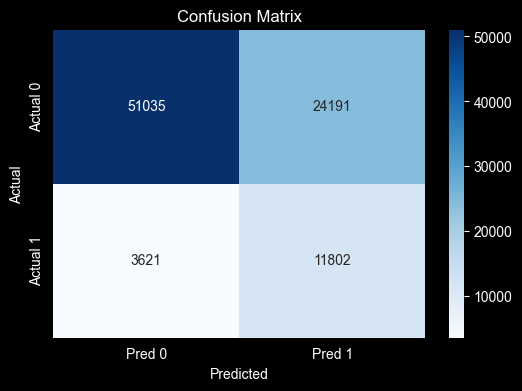

In [23]:
# 8. Plots

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred 0','Pred 1'], yticklabels=['Actual 0','Actual 1'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()